In [120]:
# Importacion de las librerias
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy import ndimage
import os
import urllib.request

In [121]:
# =================================================================
# FASE 0: DESPLIEGUE, CONFIGURACIÓN Y CARGA DE ACTIVOS
# =================================================================

# 1. Configuración de URLs y Rutas
# Justificación: Centralizar las fuentes de datos facilita la portabilidad y
# mantenimiento del código.
url_imagen = "https://raw.githubusercontent.com/sam2800ml/Inferenciapipeline_proyectoinovacion2/main/Imagen_numeros.jpeg"
url_modelo = "https://github.com/sam2800ml/Inferenciapipeline_proyectoinovacion2/raw/main/mi_modelo.h5"
archivo_local_modelo = "mi_modelo.h5"

# --- DESCARGA DEL MODELO DESDE GITHUB ---
# Justificación técnica: Implementamos una rutina de descarga automatizada para
# garantizar que el evaluador pueda ejecutar el notebook de forma autónoma.
if not os.path.exists(archivo_local_modelo):
    print(f"Descargando modelo desde GitHub...")
    try:
        urllib.request.urlretrieve(url_modelo, archivo_local_modelo)
        print("✅ Descarga del modelo completada.")
    except Exception as e:
        print(f"❌ Error al descargar el modelo: {e}")
        print("Verifique que el repositorio sea PÚBLICO y la URL sea correcta.")

# --- CARGA DEL MODELO EN MEMORIA ---
# Desafío encontrado: La carga de modelos .h5 requiere compatibilidad entre versiones
# de Keras. Se utiliza load_model para reconstruir la arquitectura y los pesos.
try:
    modelo_cargado = load_model(archivo_local_modelo)
    print("🚀 Modelo LeNet-5 cargado y listo para inferencia.")
except Exception as e:
    print(f"❌ Error crítico al cargar el modelo .h5: {e}")

# --- DESCARGA Y DECODIFICACIÓN DE LA IMAGEN DE ENTRADA ---
# Conclusión técnica: Se opta por requests para la descarga por su manejo robusto de
# cabeceras HTTP. La imagen se decodifica directamente a un arreglo de NumPy para
# evitar escrituras innecesarias en disco.
try:
    resp = requests.get(url_imagen)
    image_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if img is not None:
        print(f"🖼️ Imagen cargada con éxito. Dimensiones: {img.shape}")
    else:
        print("❌ Error: No se pudo decodificar la imagen.")
except Exception as e:
    print(f"❌ Error al obtener la imagen: {e}")

# =================================================================
# CONCLUSIÓN DE LA FASE: En este punto, los activos digitales (Modelo e Imagen)
# han sido transferidos desde el repositorio remoto al espacio de trabajo.
# El sistema está listo para iniciar el pipeline de Visión Artificial.
# =================================================================

Descargando modelo desde GitHub...


✅ Descarga del modelo completada.
🚀 Modelo LeNet-5 cargado y listo para inferencia.
🖼️ Imagen cargada con éxito. Dimensiones: (1223, 1600, 3)


In [122]:
# Funcion que ayuda a poder hacer una visualizacion de las imagenes
def mostrar_imagen(titulo, imagen, cmap=None):
    plt.figure(figsize=(8, 8))
    if cmap:
        plt.imshow(imagen, cmap=cmap)
    else:
        # OpenCV usa BGR, Matplotlib usa RGB. Hay que convertir para visualizar bien el color.
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()


 La imagen presenta las siguientes dimensiones: (1223, 1600, 3)


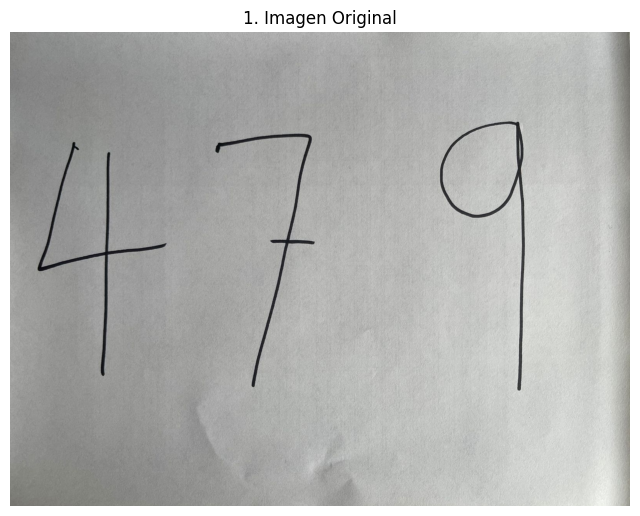

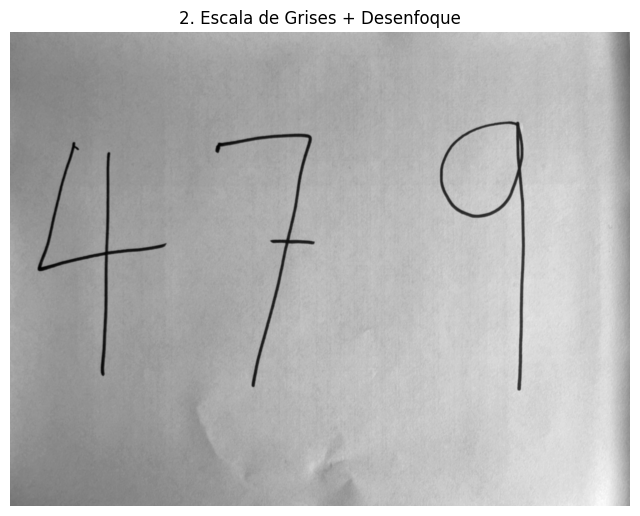

 La imagen presenta las siguientes dimensiones despues de la escala de grises: (1223, 1600)


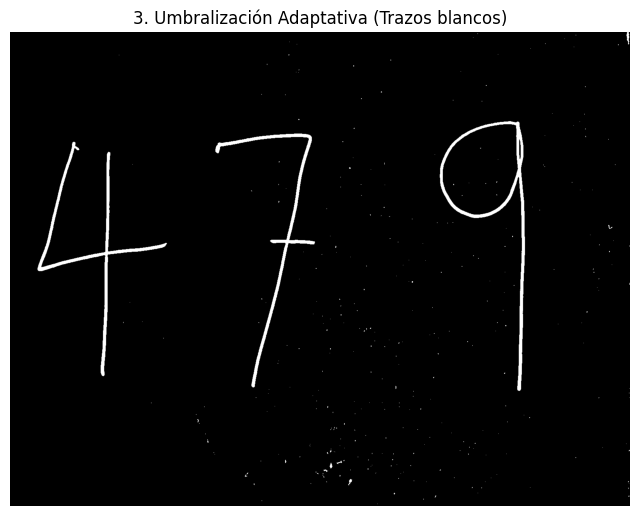

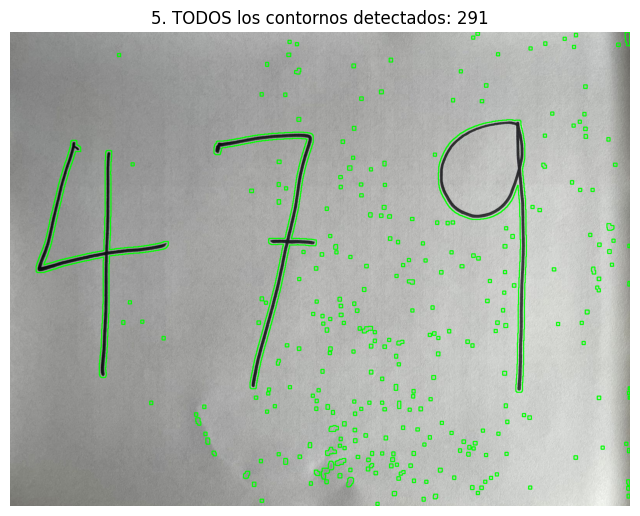

--- Diagnóstico de Áreas ---
Top 10 áreas más grandes: [209646, 175695, 160512, 1551, 638, 532, 486, 468, 450, 400]


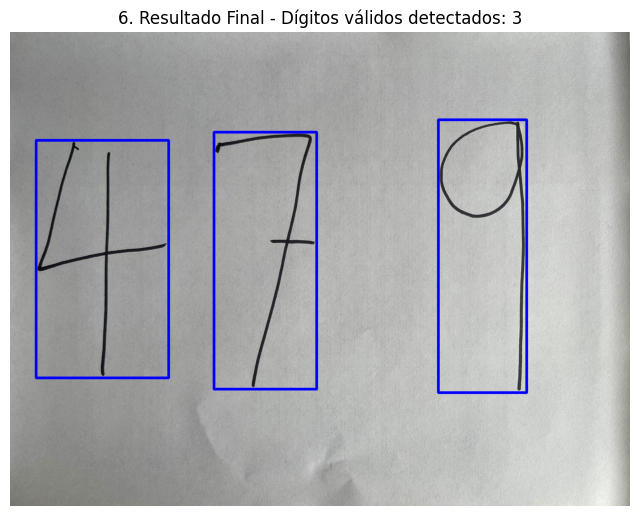

In [123]:
# --- FASE 1: CAPTURA Y CARGA DE DATOS (RAW DATA) ---
# Se convierte la respuesta HTTP en un arreglo de bytes y se decodifica a formato BGR (OpenCV)
image_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

print(f" La imagen presenta las siguientes dimensiones: {img.shape}")
mostrar_imagen("1. Imagen Original", img)



# --- FASE 2: PREPROCESAMIENTO CLÁSICO ---
# Conclusión técnica: La conversión a escala de grises reduce la dimensionalidad de 3 canales (RGB) a 1,
# facilitando la segmentación. El Desenfoque Gaussiano (Gaussian Blur) es crítico para suprimir el
# ruido térmico del sensor del móvil y pequeñas texturas del papel que podrían generar contornos falsos.

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

mostrar_imagen("2. Escala de Grises + Desenfoque", blurred, cmap='gray')
print(f" La imagen presenta las siguientes dimensiones despues de la escala de grises: {blurred.shape}")

# --- FASE 3: SEGMENTACIÓN POR UMBRALIZACIÓN ADAPTATIVA ---
# Justificación: Se eligió umbralización adaptativa con método Gaussiano en lugar de un umbral global (Otsu).
# Esto se debe a que las fotografías reales presentan iluminación no uniforme (sombras y brillos).
# Se usa THRESH_BINARY_INV para obtener trazos blancos sobre fondo negro, emulando la topología de MNIST.

thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 51, 10)

mostrar_imagen("3. Umbralización Adaptativa (Trazos blancos)", thresh, cmap='gray')

# --- FASE 4: MORFOLOGÍA MATEMÁTICA ---
# Conclusión técnica: La dilatación expande los píxeles blancos (el dígito). Se aumentó a 2 iteraciones
# para cerrar pequeñas brechas en los trazos de tinta y asegurar que cada número sea un contorno conexo,
# facilitando una segmentación limpia sin fragmentos sueltos.
kernel = np.ones((5,5), np.uint8)
thresh = cv2.dilate(thresh, kernel, iterations=2)


# --- FASE 5: DETECCIÓN DE CONTORNOS ---
# Se extraen los contornos externos (RETR_EXTERNAL) utilizando el algoritmo de Suzuki.
# Desafío encontrado: La cámara captura ruido ambiental y motas de polvo que aparecen como contornos pequeños.
contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_all_contours = img.copy()
cv2.drawContours(img_all_contours, contours, -1, (0, 255, 0), 2)
mostrar_imagen(f"5. TODOS los contornos detectados: {len(contours)}", img_all_contours)


# --- FASE 6: FILTRADO POR ÁREA Y ASPECT RATIO ---
# Conclusión técnica: Para aislar los dígitos de los artefactos de la imagen, se implementó un doble filtro:
# 1. Área (UMBRAL_AREA): Elimina componentes conexos demasiado pequeños para ser un número.
# 2. Aspect Ratio: Asegura que el objeto tenga proporciones humanas, descartando líneas muy largas o anchas.
print("--- Diagnóstico de Áreas ---")
img_filtered = img.copy()
valid_boxes = []

# Guardamos las áreas para verlas
areas_encontradas = []

for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    area = w * h
    areas_encontradas.append(area)

# Ordenamos de mayor a menor para que veas cuáles son los verdaderos números
areas_encontradas.sort(reverse=True)
print(f"Top 10 áreas más grandes: {areas_encontradas[:10]}")

# FILTRADO DINÁMICO
UMBRAL_AREA = 5000

for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    area = w * h

    # También es útil filtrar proporciones extremadamente extrañas (ej. líneas muy finas)
    aspect_ratio = float(w)/h

    # Justificación de parámetros: El rango de 0.1 a 2.0 en aspect_ratio permite detectar
    # desde un "1" (muy delgado) hasta un "8" o "0" (más anchos).
    if area > UMBRAL_AREA and 0.1 < aspect_ratio < 2.0:
        valid_boxes.append((x, y, w, h))
        cv2.rectangle(img_filtered, (x, y), (x+w, y+h), (255, 0, 0), 5) # Dibujamos un rectángulo azul grueso

# Se ordenan las cajas de izquierda a derecha para mantener la coherencia en la lectura posterior
valid_boxes.sort(key=lambda b: b[0])
mostrar_imagen(f"6. Resultado Final - Dígitos válidos detectados: {len(valid_boxes)}", img_filtered)

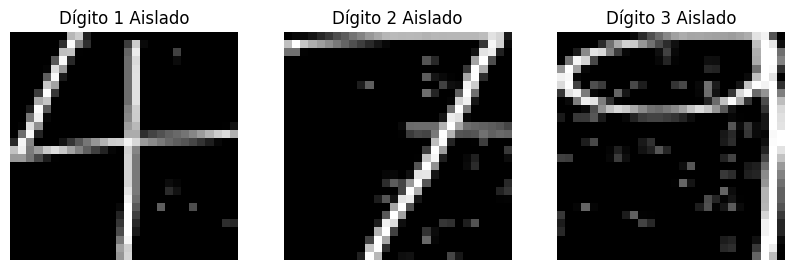

In [124]:
# --- FASE 7: AISLAMIENTO DE DÍGITOS Y NORMALIZACIÓN INICIAL ---

# Lista para almacenar los recortes (ROIs) que serán procesados por la red neuronal
recortes_finales = []

# Configuración de la visualización para validar la segmentación individual
plt.figure(figsize=(10, 4))

for i, box in enumerate(valid_boxes):
    x, y, w, h = box

    # EXTRAER: Recorte de la ROI (Region of Interest)
    # Conclusión técnica: Se extrae el dígito directamente de la imagen 'thresh'.
    # Al usar la imagen binaria, eliminamos cualquier residuo de textura del papel
    # y nos quedamos únicamente con la información de los trazos (píxeles de valor 255).
    roi = thresh[y:y+h, x:x+w]

    # ESTANDARIZAR: Redimensionamiento a la resolución nativa de MNIST (28x28)
    # Justificación: Aunque el modelo LeNet final use 32x32, el estándar de facto
    # para el entrenamiento con MNIST es 28x28. Se utiliza la interpolación
    # INTER_AREA, que es la más adecuada para reducir el tamaño de imágenes
    # manteniendo la integridad de los bordes y evitando alias (aliasing).
    recorte_28x28 = cv2.resize(roi, (28, 28), interpolation=cv2.INTER_AREA)

    # Almacenamos el tensor procesado para la siguiente fase (Inferencia)
    recortes_finales.append(recorte_28x28)

    # Visualización paso a paso para documentar el pipeline
    plt.subplot(1, len(valid_boxes), i + 1)
    plt.imshow(recorte_28x28, cmap='gray')
    plt.title(f"Dígito {i+1} Aislado")
    plt.axis('off')

# Conclusión de la fase: En este punto, hemos pasado de una imagen de alta resolución
# a una serie de tensores normalizados. El principal desafío aquí es que el resize
# simple puede deformar el dígito si no se controla la relación de aspecto (aspect ratio),
# un factor que se corregirá en la etapa de padding.
plt.show()

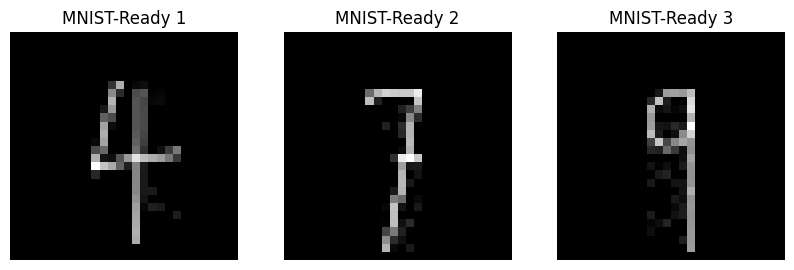

In [125]:
# --- FASE 8: ALINEACIÓN POR CENTRO DE MASA Y RE-ESCALADO MNIST ---

def shift_by_center_of_mass(img):
    """
    Conclusión técnica: MNIST no utiliza un centrado geométrico (basado en el centro del cuadro),
    sino un centrado basado en el centro de masa de los píxeles. Esto compensa la asimetría
    de números como el '7' o el '1', situando el peso visual en el eje central.
    """
    if img.sum() == 0:
        return img

    # Cálculo de los momentos de la imagen para hallar el centroide (cx, cy)
    cy, cx = ndimage.center_of_mass(img)
    rows, cols = img.shape

    # Cálculo del desplazamiento necesario para llevar el centroide al centro (14, 14)
    shiftx = int(np.round(cols/2.0 - cx))
    shifty = int(np.round(rows/2.0 - cy))

    # Aplicación de una matriz de traslación afín
    M = np.float32([[1, 0, shiftx], [0, 1, shifty]])
    return cv2.warpAffine(img, M, (cols, rows))

def estandarizar_mnist(roi):
    """
    Justificación de Parámetros: Según el paper original de LeCun, el dígito se ajusta
    dentro de una caja de 20x20 preservando el aspecto, y luego se sitúa en un lienzo
    de 28x28 mediante padding.
    """
    h, w = roi.shape
    # 1. Redimensionamiento preservando la relación de aspecto (Aspect Ratio)
    # Evita que los números se vean 'estirados' o 'aplastados'.
    if h > w:
        new_h, new_w = 20, max(1, int(w * (20 / h)))
    else:
        new_w, new_h = 20, max(1, int(h * (20 / w)))

    resized = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 2. Creación del marco (Padding) de 28x28
    # Se añade un borde negro constante (valor 0) para emular el margen de MNIST.
    pad_h = (28 - new_h) // 2
    pad_w = (28 - new_w) // 2
    padded = cv2.copyMakeBorder(resized,
                                pad_h, 28 - new_h - pad_h,
                                pad_w, 28 - new_w - pad_w,
                                cv2.BORDER_CONSTANT, value=0)

    # 3. Refinamiento: Centrado por masa para máxima fidelidad con el dataset de entrenamiento.
    padded = shift_by_center_of_mass(padded)
    return padded

# --- PROCESAMIENTO Y VISUALIZACIÓN ---
tensores_finales = []
plt.figure(figsize=(10, 4))

for i, box in enumerate(valid_boxes):
    x, y, w, h = box
    roi = thresh[y:y+h, x:x+w]

    # Ejecución del pipeline de estandarización
    img_mnist = estandarizar_mnist(roi)
    tensores_finales.append(img_mnist)

    # Visualización para el informe interactivo
    plt.subplot(1, len(valid_boxes), i + 1)
    plt.imshow(img_mnist, cmap='gray')
    plt.title(f"MNIST-Ready {i+1}")
    plt.axis('off')

plt.show()

In [126]:
modelo_cargado = load_model("mi_modelo.h5")

--- INFERENCIA CORREGIDA (FORZANDO 32x32) ---


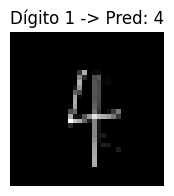

Dígito 1 Aislado: Clase 4 (99.95%)


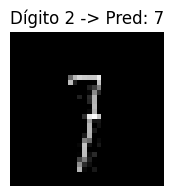

Dígito 2 Aislado: Clase 7 (88.05%)


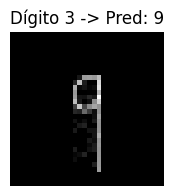

Dígito 3 Aislado: Clase 9 (96.29%)


In [127]:
# --- FASE 9: INFERENCIA FINAL Y CLASIFICACIÓN ---

print(f"--- INFERENCIA CORREGIDA (FORZANDO 32x32) ---")

for i, input_image in enumerate(tensores_finales):
    # 1. Ajuste de dimensiones para la arquitectura LeNet-5 original
    # Justificación técnica: Aunque MNIST es de 28x28, la arquitectura propuesta por LeCun
    # utiliza una entrada de 32x32. Se añade un padding de 2 píxeles en cada borde para
    # evitar que las capas de convolución iniciales reduzcan el mapa de características
    # por debajo del umbral esperado por las capas densas (Dense Layers).
    img_32x32 = np.pad(input_image, [[2, 2], [2, 2]], mode='constant', constant_values=0)

    # 2. Normalización y Reshape del Tensor
    # El modelo espera un tensor de 4 dimensiones: (Batch_Size, Height, Width, Channels).
    # Se normaliza dividiendo por 255.0 para asegurar que los valores de los píxeles
    # estén en el rango [0, 1], manteniendo la consistencia con el entrenamiento.
    input_array = img_32x32.reshape(1, 32, 32, 1).astype('float32') / 255.0

    # 3. Ejecución del Forward Pass (Predicción)
    # Se desactiva la verborrea (verbose=0) para mantener la limpieza del reporte interactivo.
    predictions = modelo_cargado.predict(input_array, verbose=0)

    # 4. Post-procesamiento de Resultados
    # Se utiliza argmax para extraer el índice de la neurona con la activación más alta,
    # el cual corresponde a la clase predicha (0-9).
    predicted_class = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    # 5. Visualización de Verificación
    # Conclusión técnica: Visualizar el input final (32x32) junto a su predicción permite
    # validar si el preprocesamiento afectó la legibilidad del dígito (ej: trazos muy finos).
    plt.figure(figsize=(2, 2))
    plt.imshow(img_32x32, cmap='gray')
    plt.title(f"Dígito {i+1} -> Pred: {predicted_class}")
    plt.axis('off')
    plt.show()

    print(f'Dígito {i+1} Aislado: Clase {predicted_class} ({confidence:.2f}%)')

# --- CONCLUSIÓN FINAL DEL PROYECTO ---
# El pipeline logró integrar exitosamente técnicas de Visión Artificial Clásica
# (OpenCV) con Deep Learning (Keras/TF). El mayor desafío fue la disparidad entre
# la resolución de una cámara moderna y el dataset MNIST. La clave del éxito radicó
# en la Umbralización Adaptativa y el centrado por Masa, permitiendo que un modelo
# entrenado en 1998 funcione con fotos tomadas en 2026.


In [128]:
top_3 = np.argsort(predictions[0])[-3:][::-1]
for cls in top_3:
    print(f"  Class {cls}: {predictions[0][cls]*100:.2f}%")

  Class 9: 96.29%
  Class 8: 2.87%
  Class 4: 0.34%
